In [1]:
import os
import random
import copy
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

import open_clip
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print(torch.cuda.is_available())

cuda
True


In [3]:
DATA_ROOT = Path(r"C:\Users\artem\Downloads\cv lab\confirmed_fronts")

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
EPOCHS_FINETUNE = 6
EPOCHS_SCRATCH = 10
LR_FINETUNE = 1e-4
LR_SCRATCH = 1e-3
WEIGHT_DECAY = 1e-4
MIN_SAMPLES_PER_CLASS = 30

In [4]:
def parse_color_from_filename(filename):
    parts = filename.split("$$")
    if len(parts) < 4:
        return None
    return parts[3].strip()

def collect_dataset(data_root):
    rows = []

    for brand_dir in data_root.iterdir():
        if not brand_dir.is_dir():
            continue

        for year_dir in brand_dir.iterdir():
            if not year_dir.is_dir():
                continue

            for image_path in year_dir.glob("*.jpg"):
                color = parse_color_from_filename(image_path.name)
                if color is None:
                    continue

                rows.append({
                    "path": str(image_path),
                    "brand": brand_dir.name,
                    "year": year_dir.name,
                    "filename": image_path.name,
                    "color": color
                })

    return pd.DataFrame(rows)

df = collect_dataset(DATA_ROOT)
df.head()

,path,brand,year,filename,color
0,C:\Users\artem\Downloads\cv lab\confirmed_fron...,Abarth,2013,Abarth$$595$$2013$$Black$$2_4$$100$$image_1.jpg,Black
1,C:\Users\artem\Downloads\cv lab\confirmed_fron...,Abarth,2013,Abarth$$595$$2013$$Black$$2_4$$191$$image_0.jpg,Black
2,C:\Users\artem\Downloads\cv lab\confirmed_fron...,Abarth,2013,Abarth$$595$$2013$$Black$$2_4$$229$$image_2.jpg,Black
3,C:\Users\artem\Downloads\cv lab\confirmed_fron...,Abarth,2013,Abarth$$595$$2013$$Black$$2_4$$236$$image_2.jpg,Black
4,C:\Users\artem\Downloads\cv lab\confirmed_fron...,Abarth,2013,Abarth$$595$$2013$$Black$$2_4$$287$$image_5.jpg,Black


In [5]:
print("Всего изображений:", len(df))
print("Количество цветов:", df["color"].nunique())
print(sorted(df["color"].unique().tolist()))
print()
print(df["color"].value_counts())

Всего изображений: 61827
Количество цветов: 23
['Beige', 'Black', 'Blue', 'Bronze', 'Brown', 'Burgundy', 'Gold', 'Green', 'Grey', 'Indigo', 'Magenta', 'Maroon', 'Multicolour', 'Navy', 'Orange', 'Pink', 'Purple', 'Red', 'Silver', 'Turquoise', 'Unlisted', 'White', 'Yellow']

color
Black          14317
Grey            9474
White           9395
Blue            8483
Silver          7770
Red             6095
Unlisted        1516
Brown            911
Green            777
Yellow           667
Beige            600
Orange           559
Purple           362
Bronze           329
Gold             217
Multicolour      196
Pink              87
Turquoise         26
Maroon            26
Burgundy           9
Magenta            9
Navy               1
Indigo             1
Name: count, dtype: int64


In [6]:
color_counts = df["color"].value_counts()
valid_colors = color_counts[color_counts >= MIN_SAMPLES_PER_CLASS].index.tolist()

df = df[df["color"].isin(valid_colors)].reset_index(drop=True)

print("После фильтрации:")
print("Всего изображений:", len(df))
print("Количество цветов:", df["color"].nunique())
print(df["color"].value_counts())

После фильтрации:
Всего изображений: 61755
Количество цветов: 17
color
Black          14317
Grey            9474
White           9395
Blue            8483
Silver          7770
Red             6095
Unlisted        1516
Brown            911
Green            777
Yellow           667
Beige            600
Orange           559
Purple           362
Bronze           329
Gold             217
Multicolour      196
Pink              87
Name: count, dtype: int64


In [7]:
df = df[~df["color"].isin(["Unlisted", "Multicolour"])]
df = df.reset_index(drop=True)

In [8]:
classes = sorted(df["color"].unique().tolist())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

df["label"] = df["color"].map(class_to_idx)

num_classes = len(classes)

print("Классы:", classes)
print("num_classes =", num_classes)

Классы: ['Beige', 'Black', 'Blue', 'Bronze', 'Brown', 'Gold', 'Green', 'Grey', 'Orange', 'Pink', 'Purple', 'Red', 'Silver', 'White', 'Yellow']
num_classes = 15


In [9]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    random_state=SEED,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=SEED,
    stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(len(train_df), len(val_df), len(test_df))

42030 9006 9007


In [10]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.03),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

clip_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.03),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711)),
])

clip_eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711)),
])

In [11]:
class CarColorDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row["path"]).convert("RGB")
        image = self.transform(image)
        label = int(row["label"])
        return image, label

In [12]:
train_dataset = CarColorDataset(train_df, train_transform)
val_dataset = CarColorDataset(val_df, eval_transform)
test_dataset = CarColorDataset(test_df, eval_transform)

clip_train_dataset = CarColorDataset(train_df, clip_train_transform)
clip_val_dataset = CarColorDataset(val_df, clip_eval_transform)
clip_test_dataset = CarColorDataset(test_df, clip_eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

clip_train_loader = DataLoader(clip_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
clip_val_loader = DataLoader(clip_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
clip_test_loader = DataLoader(clip_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [13]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    y_true = []
    y_pred = []

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        y_true.extend(labels.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())

    loss_value = total_loss / len(loader.dataset)
    f1_value = f1_score(y_true, y_pred, average="macro")
    return loss_value, f1_value

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    y_true = []
    y_pred = []

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        y_true.extend(labels.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())

    loss_value = total_loss / len(loader.dataset)
    f1_value = f1_score(y_true, y_pred, average="macro")
    return loss_value, f1_value, np.array(y_true), np.array(y_pred)

def fit_model(model, train_loader, val_loader, criterion, optimizer, device, epochs):
    history = {
        "train_loss": [],
        "train_f1": [],
        "val_loss": [],
        "val_f1": []
    }

    best_state = None
    best_val_f1 = -1

    for epoch in range(epochs):
        train_loss, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_f1, _, _ = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_f1"].append(train_f1)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(val_f1)

        print(f"Epoch {epoch + 1}/{epochs} | train_loss={train_loss:.4f} | train_f1={train_f1:.4f} | val_loss={val_loss:.4f} | val_f1={val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return model, history, best_val_f1

@torch.no_grad()
def test_model(model, loader, criterion, device):
    test_loss, test_f1, y_true, y_pred = evaluate(model, loader, criterion, device)
    return test_loss, test_f1, y_true, y_pred

In [14]:
def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_f1"], label="train_f1")
    plt.plot(epochs, history["val_f1"], label="val_f1")
    plt.title(f"{title} - F1_macro")
    plt.xlabel("Epoch")
    plt.ylabel("F1_macro")
    plt.legend()
    plt.grid(True)
    plt.show()

In [15]:
model_resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
in_features = model_resnet.fc.in_features
model_resnet.fc = nn.Linear(in_features, num_classes)
model_resnet = model_resnet.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_resnet = optim.AdamW(model_resnet.parameters(), lr=LR_FINETUNE, weight_decay=WEIGHT_DECAY)

In [16]:
model_resnet, history_resnet, best_val_f1_resnet = fit_model(
    model_resnet,
    train_loader,
    val_loader,
    criterion,
    optimizer_resnet,
    device,
    EPOCHS_FINETUNE
)

  0%|          | 0/1314 [00:00<?, ?it/s]

  0%|          | 0/282 [00:00<?, ?it/s]

Epoch 1/6 | train_loss=0.5737 | train_f1=0.5554 | val_loss=0.3852 | val_f1=0.7062


  0%|          | 0/1314 [00:00<?, ?it/s]

  0%|          | 0/282 [00:00<?, ?it/s]

...

  0%|          | 0/282 [00:00<?, ?it/s]

Epoch 5/6 | train_loss=0.1718 | train_f1=0.8494 | val_loss=0.3128 | val_f1=0.7850


  0%|          | 0/1314 [00:00<?, ?it/s]

  0%|          | 0/282 [00:00<?, ?it/s]

Epoch 6/6 | train_loss=0.1374 | train_f1=0.8857 | val_loss=0.3313 | val_f1=0.7836


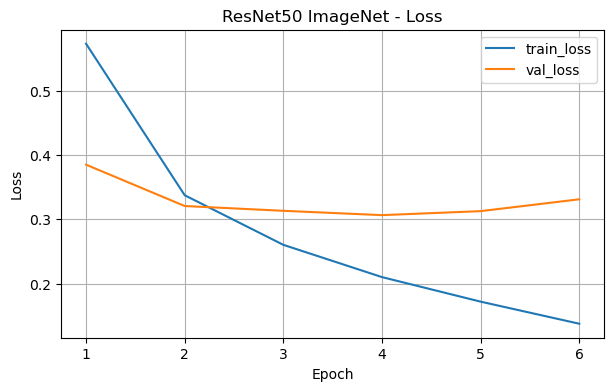

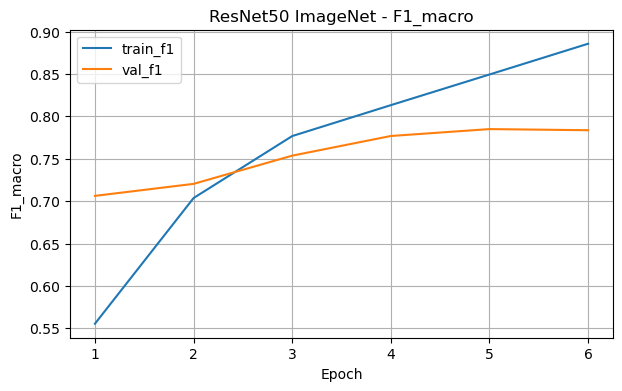

In [17]:
plot_history(history_resnet, "ResNet50 ImageNet")

In [18]:
test_loss_resnet, test_f1_resnet, y_true_resnet, y_pred_resnet = test_model(
    model_resnet,
    test_loader,
    criterion,
    device
)

print("ResNet50 test_loss:", round(test_loss_resnet, 4))
print("ResNet50 test_f1_macro:", round(test_f1_resnet, 4))
print(classification_report(y_true_resnet, y_pred_resnet, target_names=classes, digits=4))

  0%|          | 0/282 [00:00<?, ?it/s]

ResNet50 test_loss: 0.3007
ResNet50 test_f1_macro: 0.7876
              precision    recall  f1-score   support

       Beige     0.6698    0.7889    0.7245        90
       Black     0.9140    0.9693    0.9408      2148
        Blue     0.9310    0.9112    0.9210      1273
      Bronze     0.4386    0.5102    0.4717        49
       Brown     0.8267    0.4526    0.5849       137
        Gold     0.6364    0.2188    0.3256        32
       Green     0.9208    0.8017    0.8571       116
        Grey     0.9203    0.8121    0.8628      1421
      Orange     0.9180    0.6667    0.7724        84
        Pink     0.8000    0.9231    0.8571        13
      Purple     0.8857    0.5741    0.6966        54
         Red     0.9617    0.9902    0.9757       914
      Silver     0.8493    0.9571    0.9000      1166
       White     0.9774    0.9801    0.9788      1410
      Yellow     0.9495    0.9400    0.9447       100

    accuracy                         0.9160      9007
   macro avg     0.839

In [19]:
clip_backbone, _, _ = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="laion2b_s34b_b79k"
)
class CLIPColorClassifier(nn.Module):
    def __init__(self, backbone, num_classes):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Linear(backbone.visual.output_dim, num_classes)

    def forward(self, x):
        features = self.backbone.encode_image(x)
        features = features.float()
        return self.head(features)

model_clip = CLIPColorClassifier(clip_backbone, num_classes).to(device)
optimizer_clip = optim.AdamW(model_clip.parameters(), lr=1e-5, weight_decay=WEIGHT_DECAY)

In [20]:
model_clip, history_clip, best_val_f1_clip = fit_model(
    model_clip,
    clip_train_loader,
    clip_val_loader,
    criterion,
    optimizer_clip,
    device,
    EPOCHS_FINETUNE
)

  0%|          | 0/1314 [00:00<?, ?it/s]

  0%|          | 0/282 [00:00<?, ?it/s]

Epoch 1/6 | train_loss=0.5822 | train_f1=0.5413 | val_loss=0.4606 | val_f1=0.6051


  0%|          | 0/1314 [00:00<?, ?it/s]

  0%|          | 0/282 [00:00<?, ?it/s]

...

  0%|          | 0/282 [00:00<?, ?it/s]

Epoch 5/6 | train_loss=0.2108 | train_f1=0.8331 | val_loss=0.3513 | val_f1=0.7697


  0%|          | 0/1314 [00:00<?, ?it/s]

  0%|          | 0/282 [00:00<?, ?it/s]

Epoch 6/6 | train_loss=0.1807 | train_f1=0.8528 | val_loss=0.3537 | val_f1=0.7787


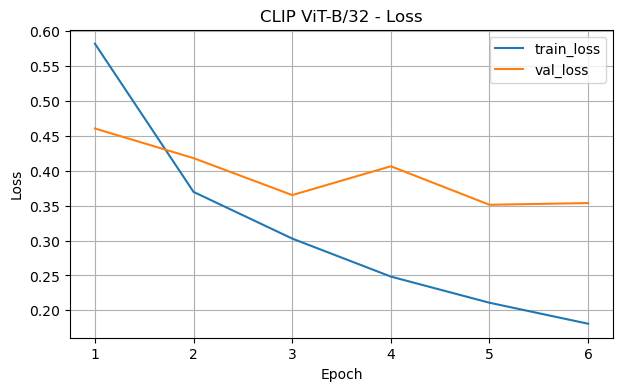

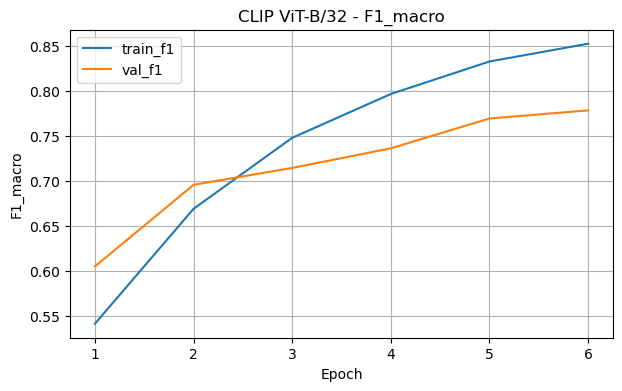

In [21]:
plot_history(history_clip, "CLIP ViT-B/32")

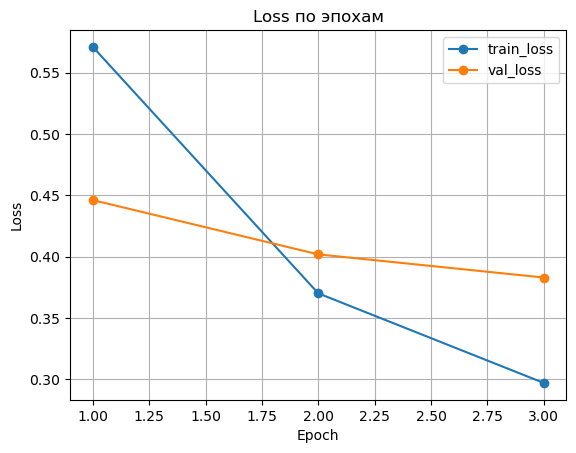

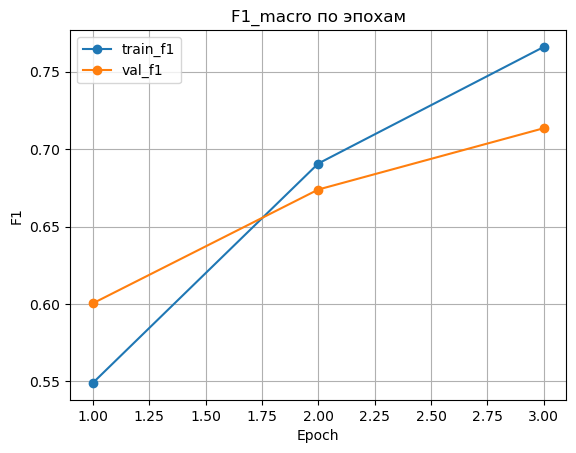

In [22]:
epochs = [1, 2, 3]

train_loss = [0.5711, 0.3700, 0.2969]
val_loss   = [0.4461, 0.4018, 0.3829]

train_f1 = [0.5490, 0.6907, 0.7660]
val_f1   = [0.6004, 0.6739, 0.7135]

plt.figure()
plt.plot(epochs, train_loss, marker='o', label='train_loss')
plt.plot(epochs, val_loss, marker='o', label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss по эпохам')
plt.legend()
plt.grid()

plt.figure()
plt.plot(epochs, train_f1, marker='o', label='train_f1')
plt.plot(epochs, val_f1, marker='o', label='val_f1')
plt.xlabel('Epoch')
plt.ylabel('F1')
plt.title('F1_macro по эпохам')
plt.legend()
plt.grid()

plt.show()

In [23]:
test_loss_clip, test_f1_clip, y_true_clip, y_pred_clip = test_model(
    model_clip,
    clip_test_loader,
    criterion,
    device
)

print("CLIP test_loss:", round(test_loss_clip, 4))
print("CLIP test_f1_macro:", round(test_f1_clip, 4))
print(classification_report(y_true_clip, y_pred_clip, target_names=classes, digits=4))

  0%|          | 0/282 [00:00<?, ?it/s]

CLIP test_loss: 0.3511
CLIP test_f1_macro: 0.7749
              precision    recall  f1-score   support

       Beige     0.6882    0.7111    0.6995        90
       Black     0.8747    0.9688    0.9194      2148
        Blue     0.9141    0.8696    0.8913      1273
      Bronze     0.5000    0.4286    0.4615        49
       Brown     0.7232    0.5912    0.6506       137
        Gold     0.5556    0.3125    0.4000        32
       Green     0.7071    0.8534    0.7734       116
        Grey     0.9106    0.7741    0.8368      1421
      Orange     0.5691    0.8333    0.6763        84
        Pink     0.8125    1.0000    0.8966        13
      Purple     0.9643    0.5000    0.6585        54
         Red     0.9743    0.9551    0.9646       914
      Silver     0.8890    0.8997    0.8943      1166
       White     0.9533    0.9837    0.9682      1410
      Yellow     0.9057    0.9600    0.9320       100

    accuracy                         0.8969      9007
   macro avg     0.7961    0.7

In [24]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_scratch = CustomCNN(num_classes).to(device)
optimizer_scratch = optim.AdamW(model_scratch.parameters(), lr=LR_SCRATCH, weight_decay=WEIGHT_DECAY)

In [25]:
model_scratch, history_scratch, best_val_f1_scratch = fit_model(
    model_scratch,
    train_loader,
    val_loader,
    criterion,
    optimizer_scratch,
    device,
    6
)

  0%|          | 0/1314 [00:00<?, ?it/s]

  0%|          | 0/282 [00:00<?, ?it/s]

Epoch 1/6 | train_loss=1.1568 | train_f1=0.3057 | val_loss=1.1541 | val_f1=0.3074


  0%|          | 0/1314 [00:00<?, ?it/s]

  0%|          | 0/282 [00:00<?, ?it/s]

...

  0%|          | 0/282 [00:00<?, ?it/s]

Epoch 5/6 | train_loss=0.7078 | train_f1=0.4650 | val_loss=0.5990 | val_f1=0.4932


  0%|          | 0/1314 [00:00<?, ?it/s]

  0%|          | 0/282 [00:00<?, ?it/s]

Epoch 6/6 | train_loss=0.6775 | train_f1=0.4769 | val_loss=0.6826 | val_f1=0.4807


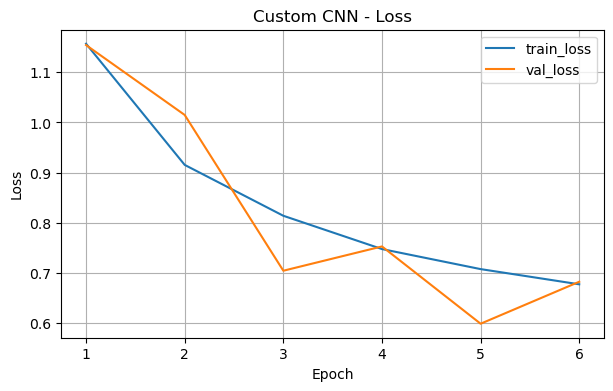

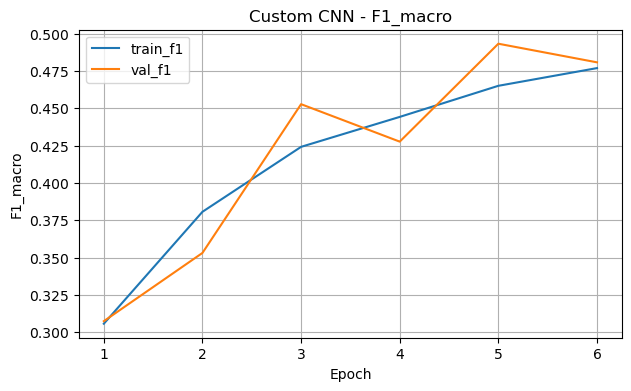

In [26]:
plot_history(history_scratch, "Custom CNN")

In [27]:
test_loss_scratch, test_f1_scratch, y_true_scratch, y_pred_scratch = test_model(
    model_scratch,
    test_loader,
    criterion,
    device
)

print("Custom CNN test_loss:", round(test_loss_scratch, 4))
print("Custom CNN test_f1_macro:", round(test_f1_scratch, 4))
print(classification_report(y_true_scratch, y_pred_scratch, target_names=classes, digits=4))

  0%|          | 0/282 [00:00<?, ?it/s]

Custom CNN test_loss: 0.603
Custom CNN test_f1_macro: 0.4978
              precision    recall  f1-score   support

       Beige     0.5395    0.4556    0.4940        90
       Black     0.7665    0.9213    0.8368      2148
        Blue     0.8534    0.7683    0.8086      1273
      Bronze     0.0000    0.0000    0.0000        49
       Brown     0.4755    0.4964    0.4857       137
        Gold     0.0000    0.0000    0.0000        32
       Green     0.8542    0.3534    0.5000       116
        Grey     0.7607    0.6242    0.6857      1421
      Orange     0.7143    0.0595    0.1099        84
        Pink     0.0000    0.0000    0.0000        13
      Purple     0.0000    0.0000    0.0000        54
         Red     0.8877    0.9770    0.9302       914
      Silver     0.7003    0.8816    0.7806      1166
       White     0.9620    0.8610    0.9087      1410
      Yellow     0.9126    0.9400    0.9261       100

    accuracy                         0.8025      9007
   macro avg     0.

c:\Users\artem\miniconda3\envs\lab1\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\artem\miniconda3\envs\lab1\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\artem\miniconda3\envs\lab1\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

In [28]:
results = pd.DataFrame({
    "model": [
        "ResNet50 ImageNet",
        "CLIP ViT-B/32",
        "Custom CNN"
    ],
    "best_val_f1": [
        best_val_f1_resnet,
        best_val_f1_clip,
        best_val_f1_scratch
    ],
    "test_f1_macro": [
        test_f1_resnet,
        test_f1_clip,
        test_f1_scratch
    ]
}).sort_values("test_f1_macro", ascending=False).reset_index(drop=True)

results

,model,best_val_f1,test_f1_macro
0,ResNet50 ImageNet,0.784992,0.787589
1,CLIP ViT-B/32,0.778684,0.774877
2,Custom CNN,0.493192,0.497751


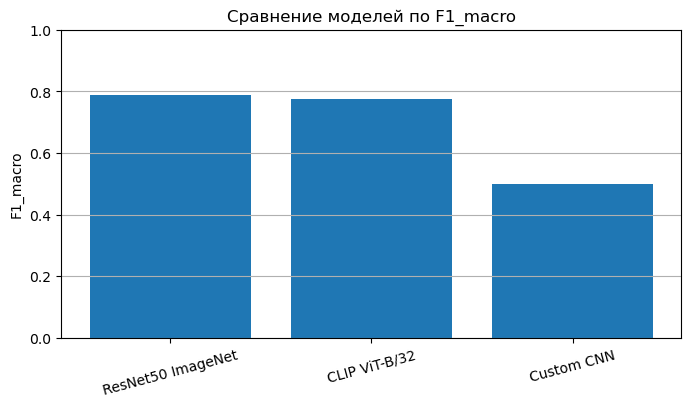

In [29]:
plt.figure(figsize=(8, 4))
plt.bar(results["model"], results["test_f1_macro"])
plt.title("Сравнение моделей по F1_macro")
plt.ylabel("F1_macro")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.grid(axis="y")
plt.show()

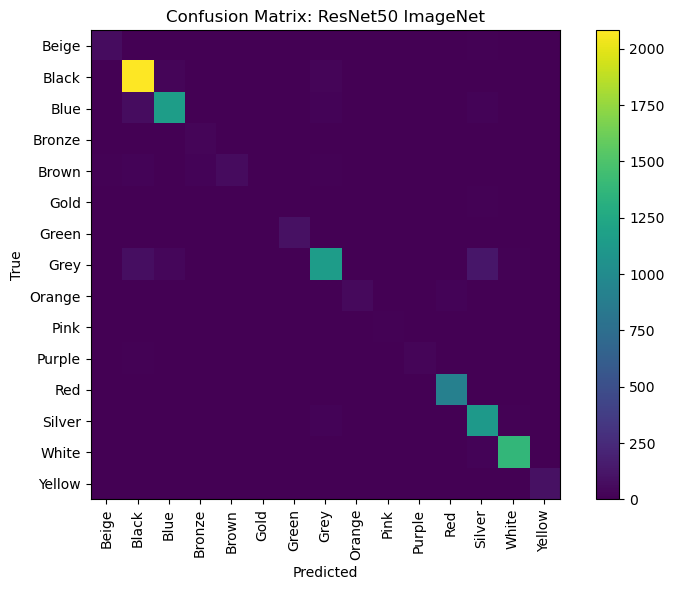

In [30]:
best_model_name = results.iloc[0]["model"]

if best_model_name == "ResNet50 ImageNet":
    y_true_best, y_pred_best = y_true_resnet, y_pred_resnet
elif best_model_name == "CLIP ViT-B/32":
    y_true_best, y_pred_best = y_true_clip, y_pred_clip
else:
    y_true_best, y_pred_best = y_true_scratch, y_pred_scratch

cm = confusion_matrix(y_true_best, y_pred_best)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.colorbar()
plt.xticks(range(num_classes), classes, rotation=90)
plt.yticks(range(num_classes), classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [31]:
best_row = results.iloc[0]
worst_row = results.iloc[-1]

print("Лучшая модель:", best_row["model"])
print("F1_macro на тесте:", round(best_row["test_f1_macro"], 4))
print()
print("Худшая модель:", worst_row["model"])
print("F1_macro на тесте:", round(worst_row["test_f1_macro"], 4))

Лучшая модель: ResNet50 ImageNet
F1_macro на тесте: 0.7876

Худшая модель: Custom CNN
F1_macro на тесте: 0.4978


Вывод
Модель, обученная с нуля, показала наихудший результат (F1_macro ≈ 0.5), что объясняется отсутствием предобученных признаков. Предобученные модели (ResNet и CLIP) продемонстрировали значительно лучшее качество, что подтверждает эффективность transfer learning.